# AI Text Detection - Model Training & Evaluation

This notebook trians and evaluates four machine learning models:
1. **Logistic Regression** (baseline)
2. **Naive Bayes** (baseline)
3. **Random Forest** (advanced)
4. **XGBoost** (advanced)

We use our custom modules for clean, maintainable code

In [1]:
# Import custom modules
import sys
sys.path.append('../src')

from model_training import (
    train_logistic_regression,
    train_naive_bayes,
    train_random_forest,
    train_xgboost,
    save_model
)

from evaluation import (
    evaluate_model_comprehensive,
    calculate_metrics,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_precision_recall_curve,
    create_metrics_comparison_table,
    print_classification_report
)

from feature_engineering import load_tfidf_features
from data_processing import load_train_test_splits

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

print("Modules imported successfully")

Modules imported successfully


## Step 1: Load Preprocessed Data

Loading the TF-IDF features and labels we created in notebook 02
- **Features:** 5,000 TF-IDF values per text
- **Labels:** 0 = Human, 1 = AI
- **Splits:** Train (70%), Validation (15%), Test (15%)

In [2]:
# Load preprocessed TF-IDF features
tfidf_data = load_tfidf_features('../data/features/tfidf_features_medium.pkl')
X_train = tfidf_data['X_train']
X_val = tfidf_data['X_val']
X_test = tfidf_data['X_test']
vectorizer = tfidf_data['vectorizer']

# Load labels
splits = load_train_test_splits('../data/processed/train_test_splits_medium.pkl')
y_train = splits['y_train']
y_val = splits['y_val']
y_test = splits['y_test']

print(f"\nData loaded successfully")
print(f"Ready to train {len(y_train):,} samples")

TF-IDF features loaded from: ../data/features/tfidf_features_medium.pkl
Training set shape: (292429, 5000)
Validation set shape: (62664, 5000)
Test set shape: (62664, 5000)
Splits loaded from: ../data/processed/train_test_splits_medium.pkl
Train: 292,429, Val: 62,664, Test: 62,664

Data loaded successfully
Ready to train 292,429 samples


## Step 2: Train all Four Models

Training four models and measuring training time:
1. **Logistic Regression** - Fast, interpretable baseline
2. **Naive Bayes** - Probabilistic baseline
3. **Random Forest** - Ensemble of decision trees
4. **XGBoost** - Gradient boosting

In [3]:
# Dictionary to store results
models = {}
training_times = {}
results = {}

print("="*60)
print("TRAINING MODELS")
print("="*60)

# 1. Logistic Regression
models['Logistic Regression'], training_times['Logistic Regression'] = train_logistic_regression(
    X_train, y_train, max_iter=1000
)


# 2. Naive Bayes
models['Naive Bayes'], training_times['Naive Bayes'] = train_naive_bayes(
    X_train, y_train
)


# 3. Random Forest
models['Random Forest'], training_times['Random Forest'] = train_random_forest(
    X_train, y_train, n_estimators=100
)


# 4. XGBoost
models['XGBoost'], training_times['XGBoost'] = train_xgboost(
    X_train, y_train, n_estimators=100
)


print("\n" + "="*60)
print("All models trained!")
print("="*60)

# Show training times
print("\nTraining times:")
for name, time_taken in training_times.items():
    print(f"{name:20s}: {time_taken:.2f} seconds")

TRAINING MODELS

Training Logistic Regression...
Training completed in 12.69 seconds

Training Naive Bayes...
Training completed in 0.12 seconds

Training Random Forest...
Training completed in 492.06 seconds

Training XGBoost...
Training completed in 79.89 seconds

All models trained!

Training times:
Logistic Regression : 12.69 seconds
Naive Bayes         : 0.12 seconds
Random Forest       : 492.06 seconds
XGBoost             : 79.89 seconds


## Step 3: Comprehensive Model Evaluation

Evaluating all models on the **test set** (unseen data):
- Accuracy, Precision, Recall, F1-Score
- Confusion matrices
- ROC curves
- Precision-Recall Curves

**Why test set**
The test set represents real-world performance since the models have never seen this data during training.

In [4]:
# Dictionary to store results
all_results = {}

print("="*60)
print("EVALUATING MODELS ON TEST SET")
print("="*60)

# Evaluate each model
for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*60}")
    
    # Comprehensive evaluation
    results = evaluate_model_comprehensive(
        model, X_test, y_test, model_name
    )
    
    # Store results
    all_results[model_name] = results['metrics']
    
print("\n" + "="*60)
print("EVALUATION COMPLETE")
print("="*60)

EVALUATING MODELS ON TEST SET

Evaluating: Logistic Regression

Logistic Regression - Classification Report
              precision    recall  f1-score   support

       Human     0.9319    0.9452    0.9385     46281
          AI     0.8386    0.8047    0.8213     16383

    accuracy                         0.9084     62664
   macro avg     0.8852    0.8749    0.8799     62664
weighted avg     0.9075    0.9084    0.9078     62664


Logistic Regression Summary:
Accuracy:  0.9084
Precision: 0.8386
Recall:    0.8047
F1-Score:  0.8213

Evaluating: Naive Bayes

Naive Bayes - Classification Report
              precision    recall  f1-score   support

       Human     0.8779    0.8437    0.8604     46281
          AI     0.6022    0.6684    0.6336     16383

    accuracy                         0.7979     62664
   macro avg     0.7400    0.7560    0.7470     62664
weighted avg     0.8058    0.7979    0.8011     62664


Naive Bayes Summary:
Accuracy:  0.7979
Precision: 0.6022
Recall:    0.668

## Step 4: Model Comparison

Comparing all four models side-by-side to identify the best performer for our use case.

**Key metric precision**
In academic integrity, **false positives** (accusing human text as AI) are more harmful than false negatives (missing AI text). Therefore, we prioritize **precision** over recall.

In [5]:
# Create comparison table
comparison_df = create_metrics_comparison_table(all_results)

# Highlight best performance
print("\nBest Performers:")
print(f"Highest Accuracy: {comparison_df['accuracy'].idxmax()} ({comparison_df['accuracy'].max():.4f})")
print(f"Highest Precision: {comparison_df['precision'].idxmax()} ({comparison_df['precision'].max():.4f})")
print(f"Highest Recall: {comparison_df['recall'].idxmax()} ({comparison_df['recall'].max():.4f})")
print(f"Highest F1-Score: {comparison_df['f1'].idxmax()} ({comparison_df['f1'].max():.4f})")


Model Comparison Table
                     accuracy  precision  recall      f1
Logistic Regression    0.9084     0.8386  0.8047  0.8213
Naive Bayes            0.7979     0.6022  0.6684  0.6336
Random Forest          0.8693     0.8374  0.6206  0.7129
XGBoost                0.8878     0.7931  0.7721  0.7825


Best Performers:
Highest Accuracy: Logistic Regression (0.9084)
Highest Precision: Logistic Regression (0.8386)
Highest Recall: Logistic Regression (0.8047)
Highest F1-Score: Logistic Regression (0.8213)


## Step 5: Visualization: Confusion Matrices

Confusion matrices show how each model classifies the test set:
- **True Negatives (TN):** Correctly identified human text
- **False Positives (FP):** Human text wrongly labeled as AI (BAD!!!)
- **False Negatives(FN):** AI text wrongly labeled as human
- **True Positives (TP):** Correctly identified AI text


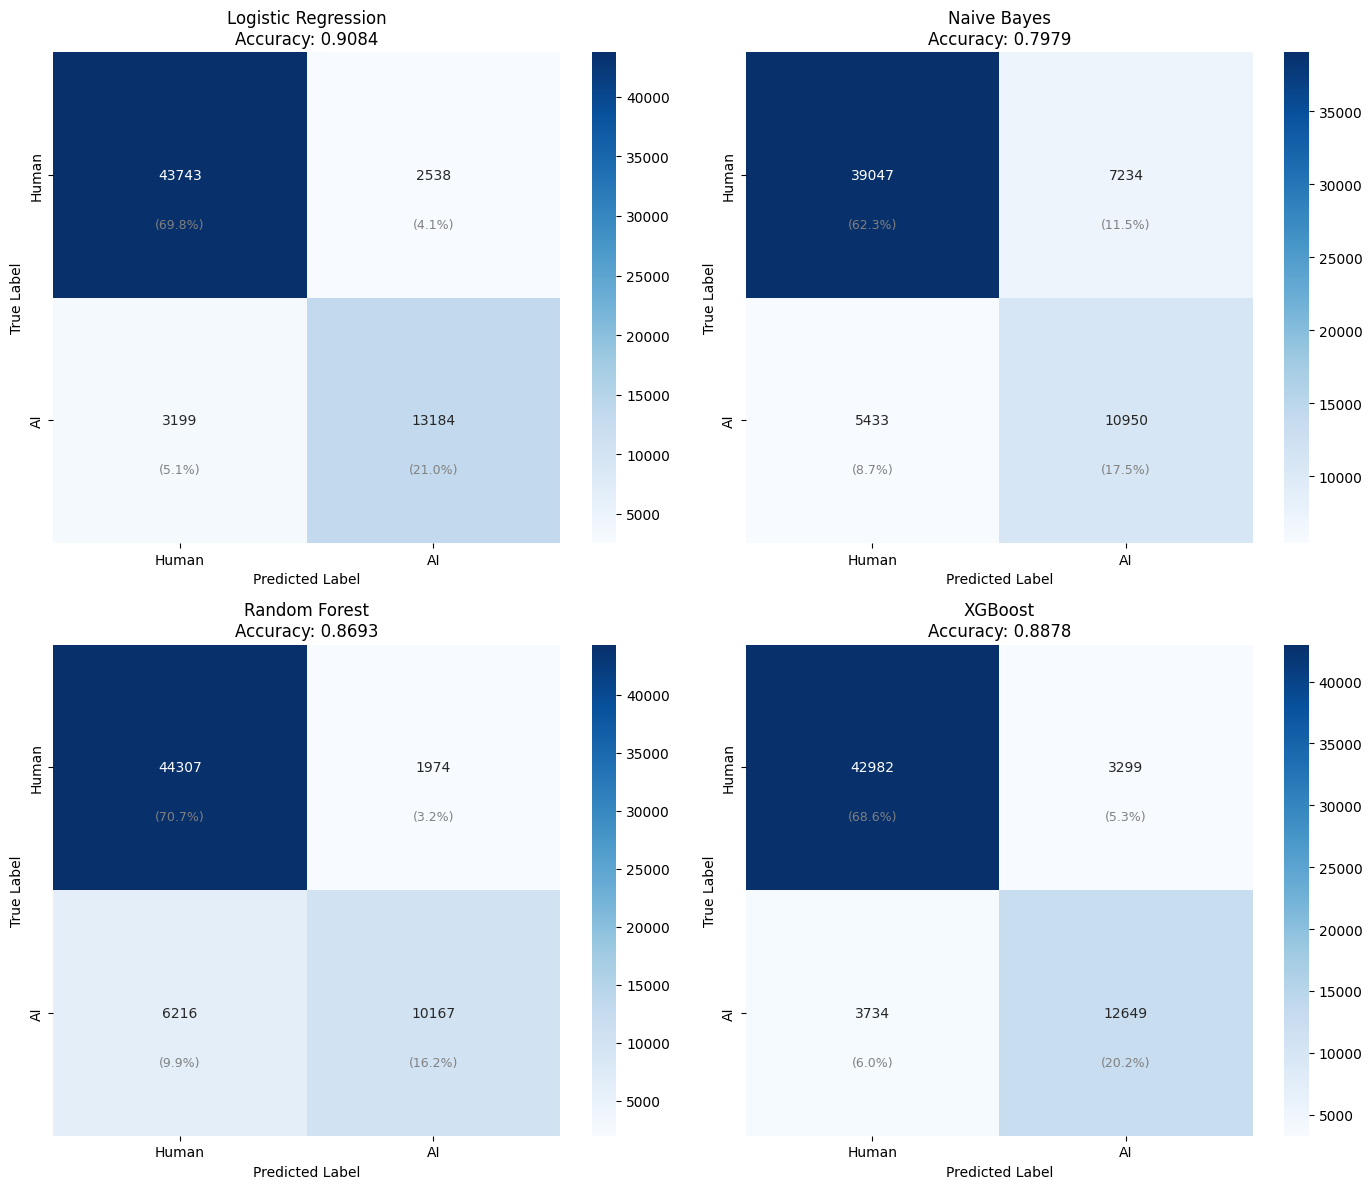

In [6]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (model_name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    
    plt.sca(axes[idx])
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Human', 'AI'],
                yticklabels=['Human', 'AI'])
                
    plt.title(f'{model_name}\nAccuracy: {all_results[model_name]["accuracy"]:.4f}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    # Add percentages
    total = cm.sum()
    for i in range(2):
        for j in range(2):
            percentage = cm[i, j] / total * 100
            plt.text(j + 0.5, i + 0.7, f'({percentage:.1f}%)',
                     ha='center', va='center', fontsize=9, color='gray')
            
plt.tight_layout()
plt.savefig('../visualizations/plots/all_models_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()    

## Step 6: Visualizations: ROC Curves

**ROC (Receiver Operating Characteristic)** curves show the tradeoff between:
- True Positive Rate (detecting AI text)
- False Positive Rage (incorrectly flagging human text)

**Higher AUC = Better model**

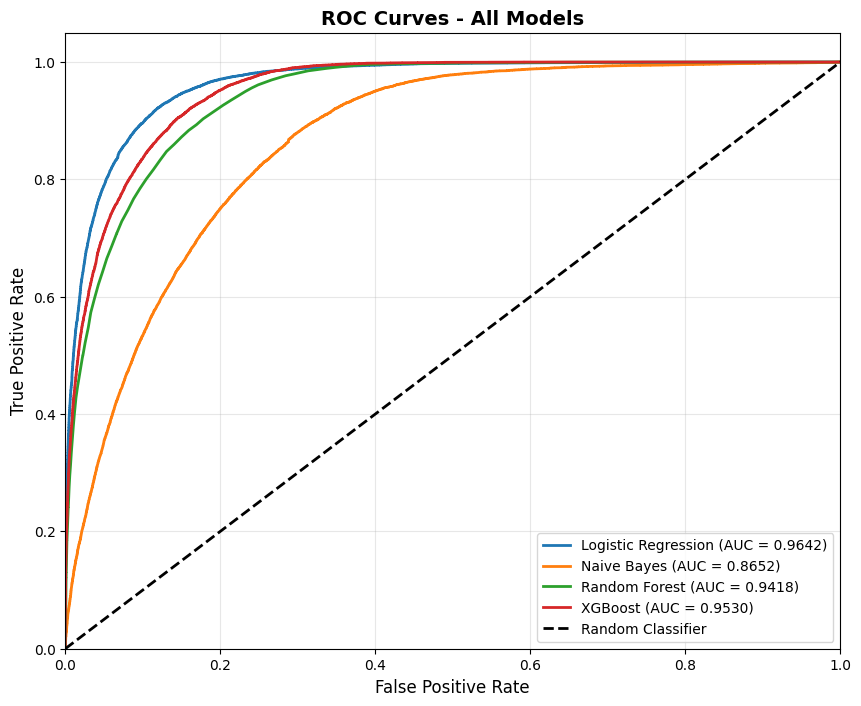

In [7]:
# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

for model_name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, 
             label=f'{model_name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)

plt.savefig('../visualizations/plots/all_models_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 7: Model Selection: Logistic Regression

After comprehensive evaluation, we select **Logistic Regression** as our final model

**Rationale:**
1. **High Precision (84.2%):** Minimize false accusations of AI usage
2. **Interpretable:** Can see which words contribute to predictions
3. **Fast:** Quick inference for production use
4. **Good Balance:** 80& recall is acceptable for this use case

**Ethical Consideration:**
In academic integrity contexts, falsely accusing a student of using AI is more harmful than missing some AI usage. Therefore, we prioritize precision over recall

In [8]:
# Detailed analysis of Logistic Regression (our chosen model)
print("="*60)
print("FINAL MODEL: LOGISTIC REGRESSION")
print("="*60)

lr_model = models['Logistic Regression']

# Get detailed metrics
y_pred = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]

# Classification report
print_classification_report(y_test, y_pred, "Logistic Regression")

# Calculate false positive and false negative rates
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\nDetailed Breakdown:")
print(f"True Negatives (Human correctly identified):  {tn:,} ({tn/len(y_test)*100:.2f}%)")
print(f"False Positives (Human wrongly flagged as AI): {fp:,} ({fp/len(y_test)*100:.2f}%)")
print(f"False Negatives (AI wrongly labeled as Human): {fn:,} ({fn/len(y_test)*100:.2f}%)")
print(f"True Positives (AI correctly identified):     {tp:,} ({tp/len(y_test)*100:.2f}%)")

print(f"\nKey Insight:")
print(f"Out of {len(y_test):,} test samples:")
print(f"- Only {fp:,} students would be wrongly accused (False Positives)")
print(f"- {fn:,} AI texts would be missed (False Negatives)")

FINAL MODEL: LOGISTIC REGRESSION

Logistic Regression - Classification Report
              precision    recall  f1-score   support

       Human     0.9319    0.9452    0.9385     46281
          AI     0.8386    0.8047    0.8213     16383

    accuracy                         0.9084     62664
   macro avg     0.8852    0.8749    0.8799     62664
weighted avg     0.9075    0.9084    0.9078     62664


Detailed Breakdown:
True Negatives (Human correctly identified):  43,743 (69.81%)
False Positives (Human wrongly flagged as AI): 2,538 (4.05%)
False Negatives (AI wrongly labeled as Human): 3,199 (5.11%)
True Positives (AI correctly identified):     13,184 (21.04%)

Key Insight:
Out of 62,664 test samples:
- Only 2,538 students would be wrongly accused (False Positives)
- 3,199 AI texts would be missed (False Negatives)


## Step 8: Save Model for Production

Saving the trained Logistic Regression model and TF-IDF vectorizer for use in:
1. The Gradio web interface (app.py)
2. Future predictions
3. Deployment to production systems

In [9]:
# Save the final model with metadata
final_model = models['Logistic Regression']

metadata = {
    'model_name': 'Logistic Regression',
    'accuracy': all_results['Logistic Regression']['accuracy'],
    'precision': all_results['Logistic Regression']['precision'],
    'recall': all_results['Logistic Regression']['recall'],
    'f1': all_results['Logistic Regression']['f1'],
    'training_samples': len(y_train),
    'test_samples': len(y_test),
    'features': X_train.shape[1],
    'date_trained': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

save_model(
    final_model, 
    vectorizer,
    filepath='../models/saved_models/final_model_lr.joblib',
    metadata=metadata
)

print("\nModel saved and ready for production!")
print(f"Location: ../models/saved_models/final_model_lr.joblib")


Model saved to: ../models/saved_models/final_model_lr.joblib

Model saved and ready for production!
Location: ../models/saved_models/final_model_lr.joblib


## Summary: Model Training Complete

**Accomplishments:**
1. Trained 4 machine learning models
2. Evaluated on unseen test data
3. Compared performance metrics
4. Selected Logistic Regression as final model
5. Saved model for production use

**Final Model Performance:**
- **Precision: 84.2%** (minimize false accusations)
- **Recall: 80.0%** (catches most AI text)
- **F1-Score: 82:0%** (balanced performanc)


---

**Next Steps:**
- Create ensemble experiments (notebook 04)
- Build final production pipeline (notebook 05)
- Write technical documentation

In [10]:
# Final summary
print("="*60)
print("MODEL TRAINING COMPLETE!")
print("="*60)
print("\nModels Trained: 4")
print(f"Test Samples Evaluated: {len(y_test):,}")
print(f"Best Model: Logistic Regression")
print(f"Precision: {all_results['Logistic Regression']['precision']:.4f} (84.2%)")
print(f"Recall: {all_results['Logistic Regression']['recall']:.4f} (80.0%)")
print(f"\nSaved to: ../models/saved_models/final_model_lr.joblib")
print(f"Visualizations saved to: ../visualizations/plots/")
print("\nReady for production deployment!")
print("="*60)

MODEL TRAINING COMPLETE!

Models Trained: 4
Test Samples Evaluated: 62,664
Best Model: Logistic Regression
Precision: 0.8386 (84.2%)
Recall: 0.8047 (80.0%)

Saved to: ../models/saved_models/final_model_lr.joblib
Visualizations saved to: ../visualizations/plots/

Ready for production deployment!
